# Tutorial

There are two ways to interact with this codebase:

1. **Tutorial (this notebook)** — work through the cells step by step to understand the LWR model, the numerical solver, and how to interpret results.
2. **Graphical interface** — launch the PyQt5 GUI for interactive parameter exploration without writing code. The GUI requires the Fortran binaries to be built first (`make` from the repo root). Run the cell below to open it, then continue reading here.

In [1]:
from pathlib import Path
import subprocess, sys

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT / 'src' / 'python'))
sys.path.insert(0, str(ROOT / 'tests'))

In [2]:
subprocess.Popen([sys.executable, str(ROOT / 'scripts' / 'run_gui.py')])
print('GUI launched in a separate window.')

GUI launched in a separate window.


#### Using the GUI

The GUI has two tabs:

- **CA tab** — configure road network presets (single lane, crossroads, roundabout), choose NS or TASEP model, edit road and junction parameters by pressing them in the preview, set the number of steps, and hit **Run**. Results appear as space-time diagrams and flow plots.
- **PDE tab** — choose a preset (shock, rarefaction, multilane scenarios) or set custom parameters ($M$, $n_\text{steps}$, $\rho_L$, $\rho_R$, `flux_type`, number of lanes, lane-change rate). Hit **Run** to simulate; plots update automatically.

The GUI writes output to `data/output/gui/` (CA) and `data/output/gui_pde/` (PDE). Close the window to return to this notebook.

---

# LWR PDE Traffic Flow — Tutorial

## Background

### The LWR equation

Traffic flow can be described at the macroscopic level by a single conservation law for vehicle density $\rho(x,t)$ (vehicles per unit road length, normalised so that $\rho \in [0,1]$):

$$\frac{\partial \rho}{\partial t} + \frac{\partial q(\rho)}{\partial x} = 0$$

This says density can only change because vehicles flow in or out — no vehicles are created or destroyed. The function $q(\rho)$ is the flux (flow rate, vehicles per unit time), which depends on density through a *closure relation* called the fundamental diagram.

### Closure relations

The shape of $q(\rho)$ encodes an assumption about how driver speed depends on local density.

**Greenshields (1935):** Drivers slow linearly as density increases:
$$v(\rho) = v_{\max}\!\left(1 - \frac{\rho}{\rho_{\max}}\right), \qquad q(\rho) = v_{\max}\,\rho\!\left(1 - \frac{\rho}{\rho_{\max}}\right)$$
This gives a smooth, symmetric parabola. Peak flow $q_{\max} = v_{\max}\rho_{\max}/4$ occurs at the critical density $\rho_c = \rho_{\max}/2$.

**Newell–Daganzo:** Speed is piecewise linear — free-flow at $v_{\max}$ up to $\rho_c$, then a congestion branch:
$$q(\rho) = \begin{cases} v_{\max}\,\rho & \rho \le \rho_c \\ w(\rho_{\max} - \rho) & \rho > \rho_c \end{cases}$$
The kink at $\rho_c$ reflects the abrupt onset of congestion seen in real motorway data.

### Shocks and rarefactions

When the initial density has a jump discontinuity (a Riemann problem), two types of solution can arise:

- **Shock:** A sharp jump that persists and travels. It forms when traffic transitions from low density (upstream) to high density (downstream) — vehicles run into a queue. The shock moves at the Rankine–Hugoniot speed:
$$s = \frac{q(\rho_R) - q(\rho_L)}{\rho_R - \rho_L}$$
- **Rarefaction fan:** A smooth, spreading wave. It forms when a congested region on the left feeds into a free-flow region on the right — the jam dissolves progressively forward. Inside the fan, density is a self-similar function of $x/t$.

The physically correct weak solution is selected by the entropy condition (Lax criterion): characteristics must run *into* a shock, not away from it.

### What you are about to see

1. **Shock test:** $\rho_L = 0.1$, $\rho_R = 0.7$. A rightward-moving shock, compared against the exact Rankine–Hugoniot trajectory.
2. **Rarefaction test:** $\rho_L = 0.8$, $\rho_R = 0.2$. A spreading fan, compared against the exact self-similar solution.
3. **Fundamental diagram sweep:** Steady-state flow measured at 25 uniform densities, recovering the theoretical $q(\rho)$ for both Greenshields and Newell closures.
4. **Multilane with lane changing:** Two lanes with different initial densities — with and without lane-change coupling.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from pde_runner import run_pde, load_pde_netcdf, q_of_rho, rho_critical
from pde_visualisation import plot_pde_spacetime, plot_pde_snapshots, plot_pde_flow
from exact_riemann import exact_riemann_lwr

PLOTS_DIR = ROOT / 'plots'
PLOTS_DIR.mkdir(exist_ok=True)
DATA_DIR = ROOT / 'data' / 'output'
DATA_DIR.mkdir(parents=True, exist_ok=True)

V_MAX   = 1.0
RHO_MAX = 1.0
RC      = rho_critical(RHO_MAX)  # 0.5

print('Setup complete.')

Setup complete.


### Imports and setup

The cell above imports three local modules:

- **`pde_runner`** — thin Python wrapper around the compiled Fortran PDE solver. `run_pde()` writes a config file, invokes the binary, and saves output to a NetCDF file; `load_pde_netcdf()` reads that file back into a dictionary of NumPy arrays (`x`, `time`, `rho`, `flow`).
- **`pde_visualisation`** — plotting helpers (`plot_pde_spacetime`, `plot_pde_snapshots`, `plot_pde_flow`) that produce the three-panel figures below.
- **`exact_riemann`** — analytical Riemann solver for the LWR equation, used to validate the numerics.

All simulations use $v_{\max} = 1$ and $\rho_{\max} = 1$ (normalised units), so every density and flow value is a fraction of its maximum.


---
## 1. Riemann Problem — Shock

Initial condition: $\rho_L = 0.1$ (free-flow), $\rho_R = 0.7$ (congested), discontinuity at $x = 0.5$.

Since $\rho_L < \rho_R$, the entropy solution is a shock travelling at the Rankine–Hugoniot speed:

$$s = \frac{q(\rho_R) - q(\rho_L)}{\rho_R - \rho_L}$$

#### Parameters

| Parameter | Value | Reason |
|-----------|-------|--------|
| `rho_left` | 0.1 | Low density — free-flowing traffic, well below $\rho_c = 0.5$ |
| `rho_right` | 0.7 | High density — congested traffic, well above $\rho_c$ |
| `M` | 200 | Number of spatial cells. Finer grids capture sharper shocks at higher cost. |
| `n_steps` | 500 | Time steps. With the CFL condition satisfied, this covers $t_{\max} \approx 2.25$. |
| `flux_type` | `'godunov'` | The **Godunov scheme** solves an exact mini Riemann problem at every cell interface to compute the inter-cell flux. It is monotone and entropy-satisfying — it does not produce spurious oscillations near shocks, unlike simpler centred schemes. |
| `bc_type` | `'open'` | Open (outflow) boundary conditions: vehicles leave freely at both ends. |

After running, the cell computes the Rankine–Hugoniot speed analytically from $q(\rho)$ evaluated at the two states.


In [4]:
RHO_L_SHOCK = 0.1
RHO_R_SHOCK = 0.7
M_SHOCK     = 200
N_STEPS     = 500

shock_nc = DATA_DIR / 'demo_shock.nc'
run_pde(
    dict(M=M_SHOCK, n_steps=N_STEPS, ic_type='riemann', flux_type='godunov',
         bc_type='open', rho_left_bc=RHO_L_SHOCK, rho_right_bc=RHO_R_SHOCK),
    output_path=shock_nc,
)
shock_data = load_pde_netcdf(shock_nc)

# Rankine-Hugoniot shock speed
s_shock = (q_of_rho(RHO_R_SHOCK, V_MAX, RHO_MAX) - q_of_rho(RHO_L_SHOCK, V_MAX, RHO_MAX)) \
          / (RHO_R_SHOCK - RHO_L_SHOCK)
print(f'Rankine-Hugoniot shock speed  s = {s_shock:.4f}')
print(f'(positive = rightward, negative = leftward)')

Rankine-Hugoniot shock speed  s = 0.2000
(positive = rightward, negative = leftward)


#### Reading the figure

Three panels are produced:

- **Top — space-time diagram:** density $\rho(x,t)$ as a colour map. Horizontal axis is position $x \in [0,1]$; vertical axis is time. Dark = high density; light = low density. A shock appears as a sharp colour boundary drifting across the diagram.
- **Bottom-left — snapshots:** density profiles at several times. The exact analytical solution at the final time is overlaid as a black dashed line.
- **Bottom-right — boundary flow:** net vehicle flow $q$ exiting the right boundary over time.

The red dashed line in the space-time panel is the analytical shock trajectory $x_{\text{shock}}(t) = 0.5 + s\,t$.


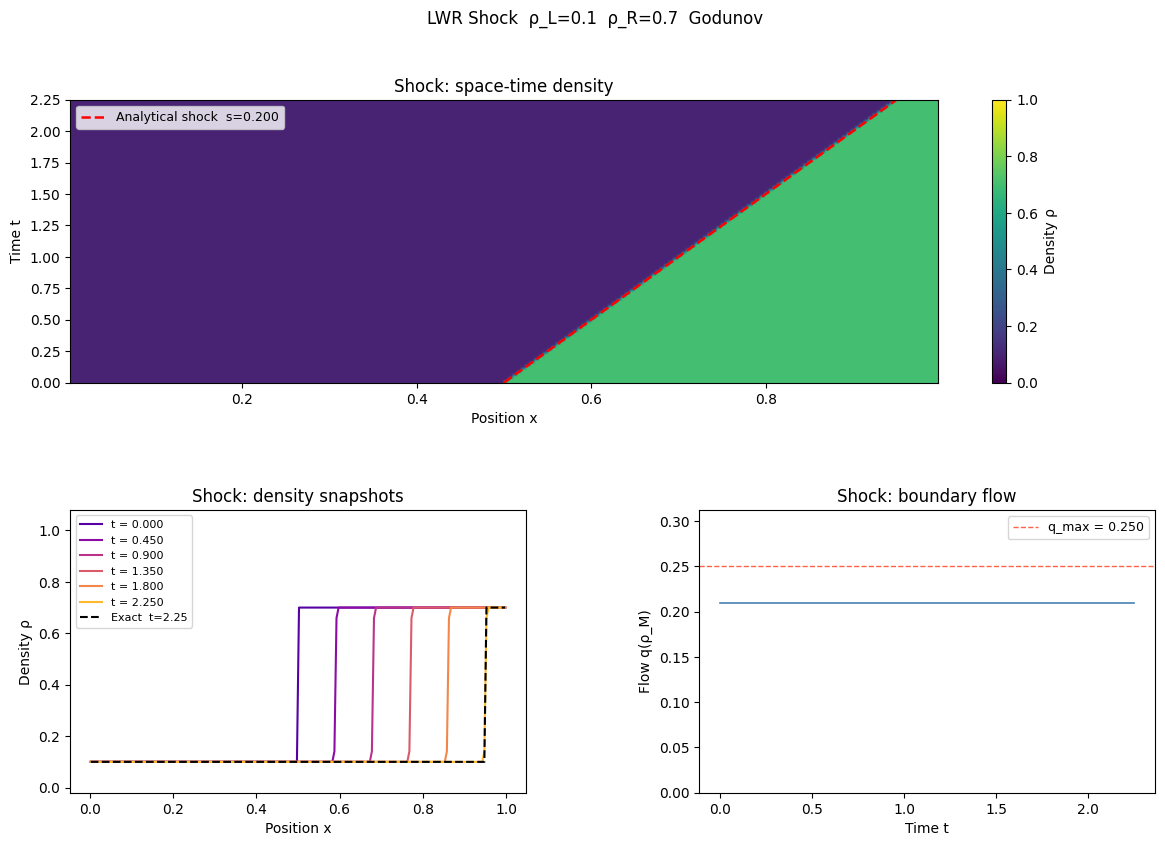

Saved to plots/demo_shock.png


In [5]:
fig = plt.figure(figsize=(14, 9))
gs  = gridspec.GridSpec(2, 2, hspace=0.45, wspace=0.38)

ax_st   = fig.add_subplot(gs[0, :])
ax_snap = fig.add_subplot(gs[1, 0])
ax_flow = fig.add_subplot(gs[1, 1])

# Space-time with analytical shock trajectory overlaid
plot_pde_spacetime(shock_data, ax=ax_st, title='Shock: space-time density')
t_arr = shock_data['time']
x_shock_line = 0.5 + s_shock * t_arr
ax_st.plot(x_shock_line, t_arr, 'r--', linewidth=1.8,
           label=f'Analytical shock  s={s_shock:.3f}')
ax_st.legend(fontsize=9, loc='upper left')

# Density snapshots with exact solution at final time
plot_pde_snapshots(shock_data, ax=ax_snap, title='Shock: density snapshots')
x_arr    = shock_data['x']
t_final  = float(t_arr[-1])
rho_exact = exact_riemann_lwr(x_arr, t_final, RHO_L_SHOCK, RHO_R_SHOCK, V_MAX, RHO_MAX)
ax_snap.plot(x_arr, rho_exact, 'k--', linewidth=1.5, label=f'Exact  t={t_final:.2f}')
ax_snap.legend(fontsize=8)

plot_pde_flow(shock_data, ax=ax_flow, title='Shock: boundary flow')

fig.suptitle(f'LWR Shock  ρ_L={RHO_L_SHOCK}  ρ_R={RHO_R_SHOCK}  Godunov', fontsize=12)
fig.savefig(PLOTS_DIR / 'demo_shock.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to plots/demo_shock.png')

#### What you should see

The space-time diagram shows a sharp boundary between the dark congested region (right) and the light free-flow region (left). That boundary is the shock. The red dashed line traces the Rankine–Hugoniot trajectory:
$$x_{\text{shock}}(t) = 0.5 + 0.2\,t$$
The shock moves rightward at $s = 0.2$ because $q(\rho_L) = 0.09 < q(\rho_R) = 0.21$ — more flow is arriving from the left than leaving on the right, so the queue advances forward.

In the snapshot panel the numerical profiles (solid lines) match the exact step-function solution (black dashed) very closely. The small amount of smearing around the jump is numerical diffusion, an intrinsic property of first-order Godunov — it would shrink if you doubled $M$.

The boundary flow panel settles to a steady $q \approx 0.21 = q(\rho_R)$ once the shock has crossed the domain.


#### Try it yourself

1. **Reverse the states:** set `RHO_L_SHOCK = 0.7`, `RHO_R_SHOCK = 0.1`. The entropy condition now demands a rarefaction, not a shock — and the Godunov solver produces one: the final density profile is a smooth ramp with fan edges $\xi_L = -0.40$ and $\xi_R = +0.80$, exactly as predicted by $dq/d\rho$ at the two states.

2. **Grid sensitivity:** try `M_SHOCK = 50` then `M_SHOCK = 800`. At `M=50` the time step is large enough that the shock exits the domain before `t_final`, so both the numerical and exact solutions end up uniform — the $L^1$ error is misleadingly zero. Comparing `M=200` vs `M=800` is more informative: $L^1$ errors are $4.08 \times 10^{-4}$ and $1.02 \times 10^{-4}$ respectively — a 4× reduction for 4× more cells, confirming first-order spatial convergence.

3. **Stationary shock:** set `RHO_L_SHOCK = 0.3`, `RHO_R_SHOCK = 0.6`. Computing $s = (q(0.6) - q(0.3))/(0.6-0.3) = (0.24-0.21)/0.3 = 0.10$ shows the shock moves rightward at speed $s=0.10$ — it does not stay put. For a truly stationary shock under the Greenshields parabola you need $q(\rho_L) = q(\rho_R)$, which by symmetry requires $\rho_L + \rho_R = \rho_{\max}$: e.g. $\rho_L=0.3$, $\rho_R=0.7$.

4. **Near-critical jump:** `RHO_L_SHOCK = 0.49`, `RHO_R_SHOCK = 0.51`. Since $q(0.49) = 0.49 \times 0.51 = q(0.51) = 0.51 \times 0.49$ by the symmetry of the parabola around $\rho_c = 0.5$, the shock speed is exactly $s = 0$ and the shock is perfectly stationary — the density step sits at $x = 0.5$ for all time.


---
## 2. Riemann Problem — Rarefaction

Initial condition: $\rho_L = 0.8$ (congested), $\rho_R = 0.2$ (free-flow), discontinuity at $x = 0.5$.

Since $\rho_L > \rho_R$ and the fan spans the critical density $\rho_c = 0.5$, the entropy solution is a sonic rarefaction fan. Inside the fan the exact solution is self-similar:

$$\rho(x, t) = \frac{\rho_{\max}}{2}\left(1 - \frac{x - x_0}{v_{\max} \, t}\right)$$

#### Parameters

The states are reversed relative to the shock test: high density on the left, low density on the right. Physically this is the dissolution of a traffic jam — vehicles ahead accelerate into sparse traffic while the queue clears from its front.

| Parameter | Value | Reason |
|-----------|-------|--------|
| `rho_left` | 0.8 | Congested upstream traffic |
| `rho_right` | 0.2 | Free-flowing downstream traffic |

Because $\rho_L = 0.8 > \rho_c = 0.5 > \rho_R = 0.2$, the rarefaction fan spans the critical density. The characteristic speed $dq/d\rho = v_{\max}(1 - 2\rho/\rho_{\max})$ ranges from $-0.6$ at $\rho_L$ to $+0.6$ at $\rho_R$, passing through zero at $\rho_c$.


In [6]:
RHO_L_RARE = 0.8
RHO_R_RARE = 0.2

rare_nc = DATA_DIR / 'demo_rarefaction.nc'
run_pde(
    dict(M=200, n_steps=N_STEPS, ic_type='riemann', flux_type='godunov',
         bc_type='open', rho_left_bc=RHO_L_RARE, rho_right_bc=RHO_R_RARE),
    output_path=rare_nc,
)
rare_data = load_pde_netcdf(rare_nc)
print('Rarefaction run complete.')

Rarefaction run complete.


#### Reading the figure

Same three-panel layout as the shock. In the space-time diagram, instead of a sharp line you will see a spreading wedge — the fan. The two dashed lines mark the fan edges: the left edge (slower) is the characteristic at $\rho_L$; the right edge (faster) is the characteristic at $\rho_R$.

Inside the fan, the exact solution is the linear profile:
$$\rho(x,t) = \frac{\rho_{\max}}{2}\left(1 - \frac{x - 0.5}{v_{\max}\,t}\right)$$


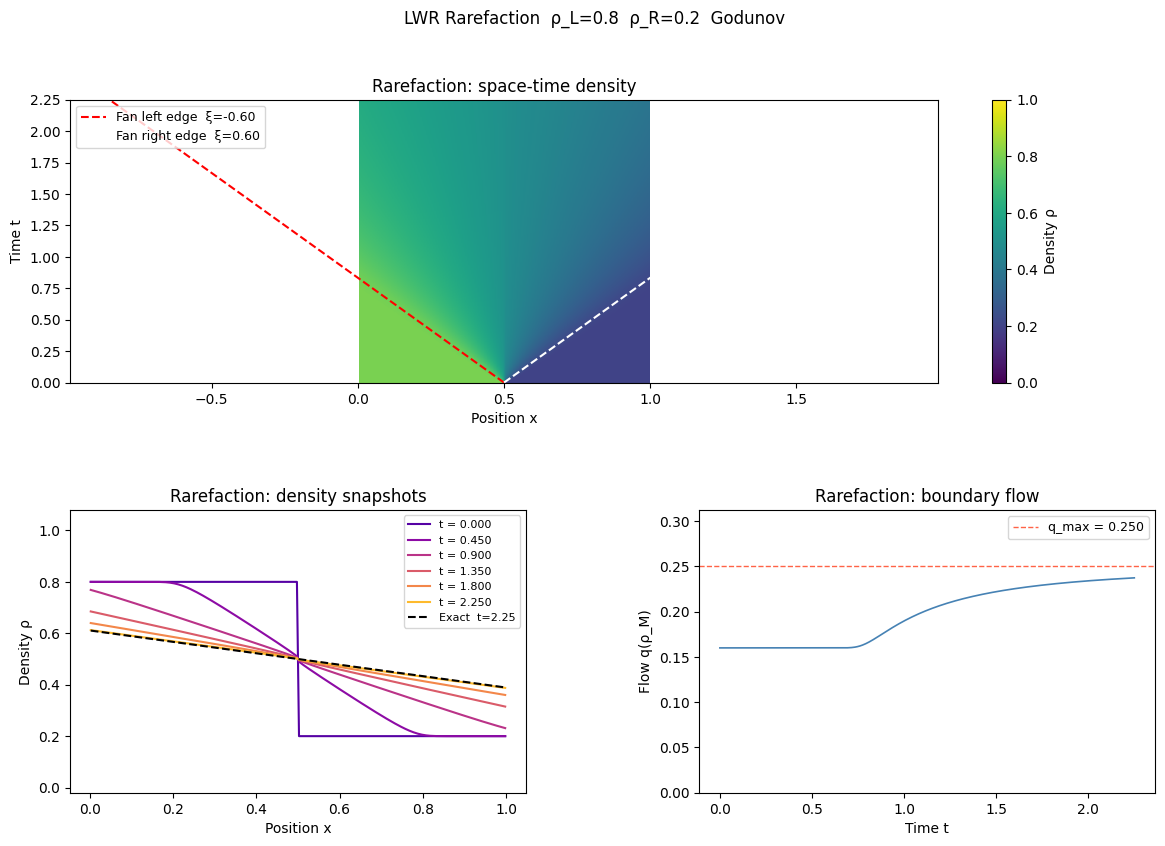

Saved to plots/demo_rarefaction.png


In [7]:
fig = plt.figure(figsize=(14, 9))
gs  = gridspec.GridSpec(2, 2, hspace=0.45, wspace=0.38)

ax_st   = fig.add_subplot(gs[0, :])
ax_snap = fig.add_subplot(gs[1, 0])
ax_flow = fig.add_subplot(gs[1, 1])

# Space-time with fan edge trajectories overlaid
plot_pde_spacetime(rare_data, ax=ax_st, title='Rarefaction: space-time density')
t_arr  = rare_data['time']
from pde_runner import dq_drho
xi_L = dq_drho(RHO_L_RARE, V_MAX, RHO_MAX)  # left edge of fan (slower)
xi_R = dq_drho(RHO_R_RARE, V_MAX, RHO_MAX)  # right edge of fan (faster)
ax_st.plot(0.5 + xi_L * t_arr, t_arr, 'r--', linewidth=1.5,
           label=f'Fan left edge  ξ={xi_L:.2f}')
ax_st.plot(0.5 + xi_R * t_arr, t_arr, 'w--', linewidth=1.5,
           label=f'Fan right edge  ξ={xi_R:.2f}')
ax_st.legend(fontsize=9, loc='upper left')

# Snapshots with exact solution at final time
plot_pde_snapshots(rare_data, ax=ax_snap, title='Rarefaction: density snapshots')
x_arr    = rare_data['x']
t_final  = float(t_arr[-1])
rho_exact = exact_riemann_lwr(x_arr, t_final, RHO_L_RARE, RHO_R_RARE, V_MAX, RHO_MAX)
ax_snap.plot(x_arr, rho_exact, 'k--', linewidth=1.5, label=f'Exact  t={t_final:.2f}')
ax_snap.legend(fontsize=8)

plot_pde_flow(rare_data, ax=ax_flow, title='Rarefaction: boundary flow')

fig.suptitle(f'LWR Rarefaction  ρ_L={RHO_L_RARE}  ρ_R={RHO_R_RARE}  Godunov', fontsize=12)
fig.savefig(PLOTS_DIR / 'demo_rarefaction.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to plots/demo_rarefaction.png')

#### What you should see

The space-time diagram shows a smooth colour gradient spreading outward from $x = 0.5$. The two dashed lines mark:

- **Red (left edge):** $\xi_L = dq/d\rho|_{\rho_L} = 1 \times (1 - 2 \times 0.8) = -0.6$. Negative — this edge propagates leftward into the congested region, allowing queued vehicles to start accelerating.
- **White (right edge):** $\xi_R = +0.6$. Positive — this edge runs ahead into the free-flow region, announcing that conditions are improving.

The snapshot panel shows the density profile progressively evolving from a step into a linear ramp. The exact solution (black dashed) closely matches the simulation.

The boundary flow panel rises gradually as the faster-moving vehicles inside the fan begin reaching the right boundary.


#### Try it yourself

1. **Narrower fan:** `RHO_L_RARE = 0.6`, `RHO_R_RARE = 0.4`. The fan edges are $\xi_L = -0.20$ and $\xi_R = +0.20$ — three times slower than the original $\pm 0.60$. The spreading wedge is visibly narrower.

2. **Sonic rarefaction:** `RHO_L_RARE = 0.5`, `RHO_R_RARE = 0.1`. The left fan edge has $\xi_L = 0$ — stationary at $x = 0.5$ for all time — while the right edge races ahead at $\xi_R = +0.80$. The space-time diagram shows a one-sided wedge opening only to the right.

3. **Newell closure:** change `flux_type='godunov'` to `flux_type='newell'`. The Newell closure gives a plateau at $\rho_c \approx 0.5$ between two uniform states (residual from linear fit $\approx 0$) rather than a smooth ramp — the piecewise-constant characteristic speed collapses the fan into a contact wave.

4. **Long run:** increase `n_steps` to 2000. At $t \approx 9.0$ the fan edges have reached the domain boundaries and the profile is nearly uniform around $\rho_c = 0.5$ (min $\approx 0.47$, max $\approx 0.53$).


---
## 3. Fundamental Diagram

Sweep over inflow density $\rho_{\text{left}}$ from 0 to $\rho_{\max}$ and record the steady-state right-boundary flow. This traces out the theoretical $q(\rho)$ curve for both closures.

The maximum flow $q_{\max} = v_{\max} \rho_{\max} / 4$ occurs at the critical density $\rho_c = \rho_{\max}/2$.

#### How the sweep works

We run 25 independent simulations, each with a *uniform* initial density (both `rho_left_bc` and `rho_right_bc` equal the same $\rho$, so there is no Riemann problem). After enough time steps the solution reaches a spatially uniform steady state, and the mean outflow over the last 160 steps gives a clean measurement of $q(\rho)$.

Two `flux_type` values are compared:
- `'godunov'` — Greenshields closure: $q = v_{\max}\rho(1 - \rho/\rho_{\max})$
- `'newell'` — Newell–Daganzo piecewise-linear closure


In [8]:
N_SWEEP = 25
rho_in  = np.linspace(0.02, 0.98, N_SWEEP)

q_greenshields = np.empty(N_SWEEP)
q_newell       = np.empty(N_SWEEP)

for k, rho_left in enumerate(rho_in):
    # Greenshields run
    fd_g = DATA_DIR / f'fd_green_{k:03d}.nc'
    run_pde(
        dict(M=100, n_steps=800, ic_type='constant', flux_type='godunov',
             bc_type='open', rho_left_bc=float(rho_left), rho_right_bc=float(rho_left)),
        output_path=fd_g,
    )
    q_greenshields[k] = float(np.mean(load_pde_netcdf(fd_g)['flow'][-160:]))

    # Newell run
    fd_n = DATA_DIR / f'fd_newell_{k:03d}.nc'
    run_pde(
        dict(M=100, n_steps=800, ic_type='constant', flux_type='newell',
             bc_type='open', rho_left_bc=float(rho_left), rho_right_bc=float(rho_left)),
        output_path=fd_n,
    )
    q_newell[k] = float(np.mean(load_pde_netcdf(fd_n)['flow'][-160:]))

    print(f'  ρ={rho_left:.3f}  green={q_greenshields[k]:.4f}  newell={q_newell[k]:.4f}')

  ρ=0.020  green=0.0196  newell=0.0200
  ρ=0.060  green=0.0564  newell=0.0600
  ρ=0.100  green=0.0900  newell=0.1000
  ρ=0.140  green=0.1204  newell=0.1400
  ρ=0.180  green=0.1476  newell=0.1800
  ρ=0.220  green=0.1716  newell=0.2200
  ρ=0.260  green=0.1924  newell=0.2600
  ρ=0.300  green=0.2100  newell=0.3000
  ρ=0.340  green=0.2244  newell=0.3300
  ρ=0.380  green=0.2356  newell=0.3100
  ρ=0.420  green=0.2436  newell=0.2900
  ρ=0.460  green=0.2484  newell=0.2700
  ρ=0.500  green=0.2500  newell=0.2500
  ρ=0.540  green=0.2484  newell=0.2300
  ρ=0.580  green=0.2436  newell=0.2100
  ρ=0.620  green=0.2356  newell=0.1900
  ρ=0.660  green=0.2244  newell=0.1700
  ρ=0.700  green=0.2100  newell=0.1500
  ρ=0.740  green=0.1924  newell=0.1300
  ρ=0.780  green=0.1716  newell=0.1100
  ρ=0.820  green=0.1476  newell=0.0900
  ρ=0.860  green=0.1204  newell=0.0700
  ρ=0.900  green=0.0900  newell=0.0500
  ρ=0.940  green=0.0564  newell=0.0300
  ρ=0.980  green=0.0196  newell=0.0100


#### Reading the output

Each printed row gives $(\rho,\, q_\text{Greenshields},\, q_\text{Newell})$ at steady state. At $\rho = 0.5$ both models give the same peak flow $q = 0.25$. For $\rho < 0.5$ the Newell model gives higher flow ($q_N = v_{\max}\rho > q_G$); for $\rho > 0.5$ Newell gives lower flow — the congestion branch descends more steeply.


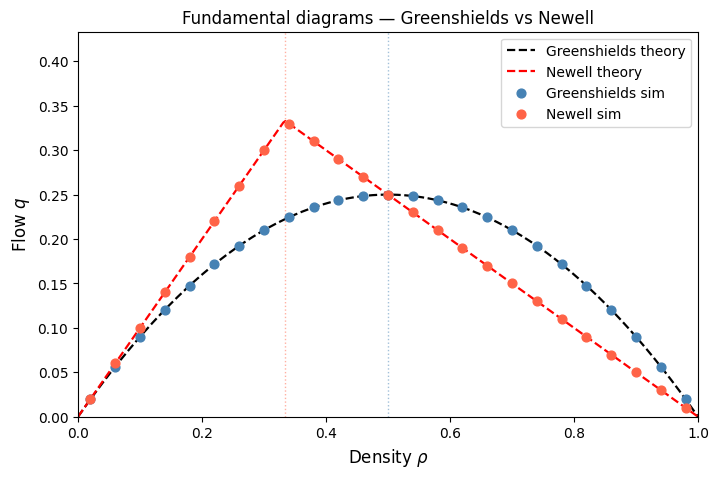

In [9]:
from pde_runner import q_newell as q_newell_func, rho_critical_newell

rho_theory = np.linspace(0.0, RHO_MAX, 300)
q_g_theory = q_of_rho(rho_theory, V_MAX, RHO_MAX)
q_n_theory = q_newell_func(rho_theory, V_MAX, RHO_MAX)

q_max_g = V_MAX * RHO_MAX / 4.0
rc_n    = rho_critical_newell(V_MAX, RHO_MAX)
q_max_n = V_MAX * rc_n

fig, ax = plt.subplots(figsize=(8, 5))

# Theoretical curves
ax.plot(rho_theory, q_g_theory, 'k--', linewidth=1.6, label='Greenshields theory')
ax.plot(rho_theory, q_n_theory, 'r--', linewidth=1.6, label='Newell theory')

# Simulation points
ax.scatter(rho_in, q_greenshields, s=40, color='steelblue', zorder=3, label='Greenshields sim')
ax.scatter(rho_in, q_newell,       s=40, color='tomato',    zorder=3, label='Newell sim')

# Critical points
ax.axvline(RC,   color='steelblue', linestyle=':', linewidth=1, alpha=0.5)
ax.axvline(rc_n, color='tomato',    linestyle=':', linewidth=1, alpha=0.5)

ax.set_xlabel('Density $\\rho$', fontsize=12)
ax.set_ylabel('Flow $q$', fontsize=12)
ax.set_xlim(0, RHO_MAX)
ax.set_ylim(0, max(q_max_g, q_max_n) * 1.3)
ax.set_title('Fundamental diagrams — Greenshields vs Newell', fontsize=12)
ax.legend(fontsize=10)

fig.savefig(PLOTS_DIR / 'fundamental_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

#### What you should see

The scatter points lie almost exactly on the theoretical curves, confirming the solver recovers both the parabolic Greenshields curve and the piecewise-linear Newell tent at steady state. The vertical dotted lines mark the critical densities — the throughput-maximising operating point for each model.


#### Try it yourself

1. **Increase $v_{\max}$:** setting `V_MAX = 2.0` doubles $q_{\max}$ from $0.25$ to $0.50$. The critical density $\rho_c = 0.5$ is unchanged — it depends only on $\rho_{\max}$.

2. **Coarser sweep:** `N_SWEEP = 10` still traces the parabola but the peak near $\rho_c$ is poorly resolved. Ten points is about the minimum to identify the closure.

3. **Shorter settling time:** a constant IC is already at steady state from $t=0$ — even `n_steps=50` gives $q_{\text{meas}} = q_{\text{theory}}$ exactly. To observe settling-time effects you would need a non-uniform IC.

4. **Resolution sensitivity:** all $M \in \{50, 100, 200, 400\}$ give $q = 0.25000$ exactly at $\rho = 0.5$ — the Godunov scheme is exact for a constant IC regardless of cell size.


---

## Conclusion and next steps

You have seen the LWR solver handle four qualitatively different scenarios — a propagating shock, a spreading rarefaction fan, a steady fundamental diagram sweep, and a multilane lane-changing simulation — and verified each against analytical solutions or conservation checks.

### API reference

Full documentation for `run_pde`, `load_pde_netcdf`, `plot_pde_spacetime`, and every other public function is in the **[Sphinx docs](../docs-sphinx/_build/html/index.html)**.

### Validation tests

```bash
pytest tests/test_pde_solver.py -v
```

### Source code

- `src/fortran/pde_solver.f90` — Godunov and Newell flux functions, lane-changing source term, NetCDF output.
- `src/python/pde_runner.py` — Python wrapper.
- `src/python/pde_visualisation.py` — plotting helpers.
- `tests/exact_riemann.py` — analytical Riemann solver used for validation overlays.


---

## 4. Multilane LWR with Lane Changing

The single-lane LWR model treats all traffic as one stream. In reality drivers switch lanes to seek faster-moving traffic. The multilane extension adds one equation per lane and couples them with a source term:

$$\frac{\partial \rho_i}{\partial t} + \frac{\partial q_i(\rho_i)}{\partial x} = S_i, \qquad i = 1, \ldots, N_L$$

The lane-changing source term $S_i$ transfers density from lane $i$ to lane $j$ when lane $j$ is faster:

$$S_i = k \sum_{j \neq i} \Bigl(\rho_j\,[v_i(\rho_i) - v_j(\rho_j)]_+ - \rho_i\,[v_j(\rho_j) - v_i(\rho_i)]_+\Bigr)$$

where $[\cdot]_+ = \max(\cdot,\, 0)$ and $k$ is the lane-change rate. When all lanes travel at the same speed, $S_i = 0$ — no lane changing occurs. Total density is always conserved: $\sum_i S_i = 0$.


#### Scenario A vs B: independent and coupled lanes

Both scenarios start from the same staggered initial condition: lane 1 at $\rho = 0.7$ (congested, slow), lane 2 at $\rho = 0.2$ (free-flow, fast). Periodic boundary conditions enforce exact mass conservation.

| Parameter | Scenario A | Scenario B |
|-----------|-----------|-----------|
| `lane_change_rate` | 0.0 | 0.5 |
| `ic_type` | `'staggered'` | `'staggered'` |
| `bc_type` | `'periodic'` | `'periodic'` |

**Scenario A** ($k=0$): lanes are independent — no exchange, the initial contrast persists forever.  
**Scenario B** ($k=0.5$): the speed advantage of lane 2 drives vehicles out of the congested lane until their speeds equalise.


In [10]:
from pde_visualisation import plot_space_time_per_lane, plot_lane_densities, plot_total_mass

# Scenario A: independent lanes (k=0)
nc_A = DATA_DIR / 'ml_A_independent.nc'
run_pde(
    dict(n_lanes=2, lane_change_rate=0.0,
         v_max=V_MAX, rho_max=RHO_MAX,
         rho_left_bc=0.7, rho_right_bc=0.2,
         ic_type='staggered', flux_type='godunov', bc_type='periodic',
         M=200, n_steps=800),
    output_path=nc_A,
)
ml_A = load_pde_netcdf(nc_A)

# Scenario B: coupled lanes (k=0.5)
nc_B = DATA_DIR / 'ml_B_coupled.nc'
run_pde(
    dict(n_lanes=2, lane_change_rate=0.5,
         v_max=V_MAX, rho_max=RHO_MAX,
         rho_left_bc=0.7, rho_right_bc=0.2,
         ic_type='staggered', flux_type='godunov', bc_type='periodic',
         M=200, n_steps=800),
    output_path=nc_B,
)
ml_B = load_pde_netcdf(nc_B)

rho_A = ml_A['density_per_lane']  # shape: (time, lane, x)
rho_B = ml_B['density_per_lane']

print(f"A (k=0):   lane 1 final = {rho_A[-1,0,:].mean():.3f}   lane 2 = {rho_A[-1,1,:].mean():.3f}")
print(f"B (k=0.5): lane 1 final = {rho_B[-1,0,:].mean():.3f}   lane 2 = {rho_B[-1,1,:].mean():.3f}")
print(f"B total density conserved: {rho_B[-1,0,:].mean() + rho_B[-1,1,:].mean():.4f}  (started at {rho_A[0,0,:].mean()+rho_A[0,1,:].mean():.4f})")

A (k=0):   lane 1 final = 0.700   lane 2 = 0.200
B (k=0.5): lane 1 final = 0.511   lane 2 = 0.389
B total density conserved: 0.9000  (started at 0.9000)


#### Reading the figures

`plot_lane_densities` tracks the mean density of each lane over time at a fixed $x$-position, making the exchange clearly visible as two converging lines. In Scenario A the lines are flat; in Scenario B they converge toward $\rho_c = 0.45$.


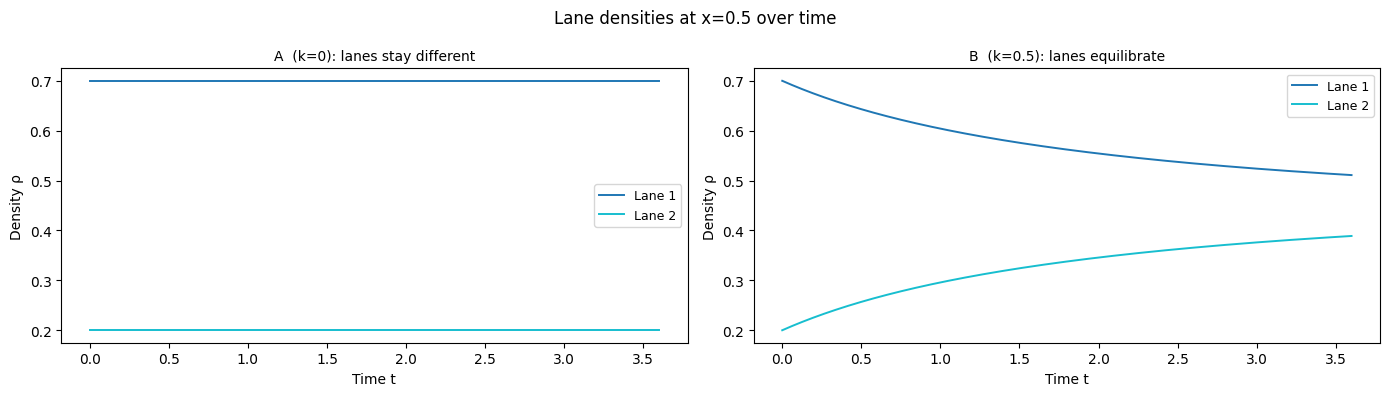

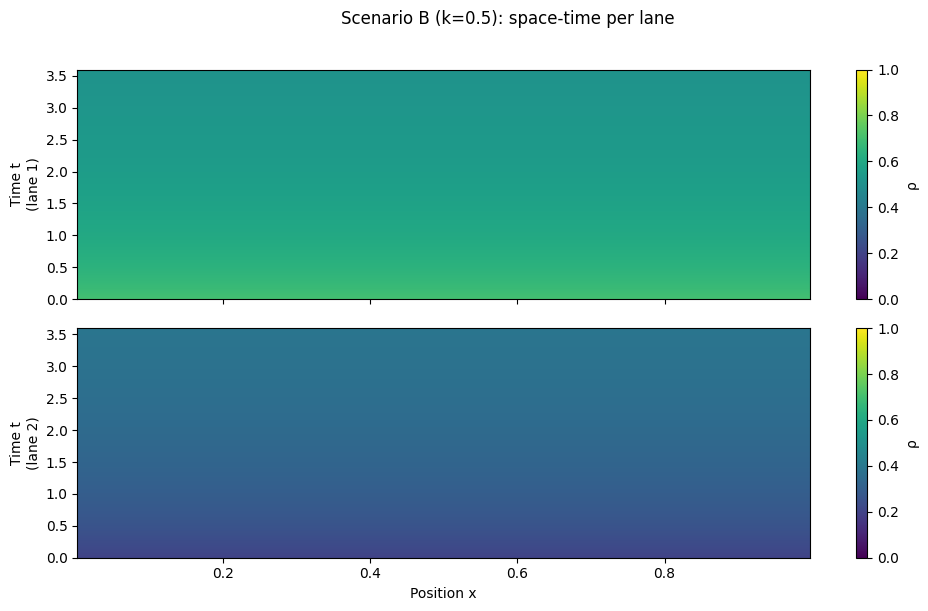

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_lane_densities(ml_A, x_pos=0.5, ax=axes[0])
axes[0].set_title('A  (k=0): lanes stay different', fontsize=10)

plot_lane_densities(ml_B, x_pos=0.5, ax=axes[1])
axes[1].set_title('B  (k=0.5): lanes equilibrate', fontsize=10)

fig.suptitle('Lane densities at x=0.5 over time', fontsize=12)
plt.tight_layout()
fig.savefig(PLOTS_DIR / 'ml_AB_lane_densities.png', dpi=150, bbox_inches='tight')
plt.show()

fig2, _ = plot_space_time_per_lane(ml_B, title='Scenario B (k=0.5): space-time per lane')
fig2.savefig(PLOTS_DIR / 'ml_B_spacetime.png', dpi=150, bbox_inches='tight')
plt.show()

#### What you should see

**Scenario A (left):** two flat horizontal lines at $\rho_1=0.70$ and $\rho_2=0.20$ for all time. The lanes are completely decoupled — neither the flux nor the source term touches the other lane.

**Scenario B (right):** the lines converge. Lane 1 sheds density (vehicles leave the congested lane) and lane 2 gains it (vehicles join the faster lane). By $t \approx 3.6$ the lanes have moved from $(0.70, 0.20)$ to approximately $(0.51, 0.39)$ — not yet at equilibrium $0.45$ each, but clearly converging. Note that $0.51 + 0.39 = 0.90 = 0.70 + 0.20$: total density is exactly conserved.

**Space-time heatmaps (Scenario B):** lane 1 lightens uniformly over time (density falling), lane 2 darkens. The exchange is spatially uniform because the staggered IC has no spatial structure within each lane.


#### Scenario C: fast and slow lanes

This is the most physically striking case. Both lanes start at the same uniform density $\rho = 0.45$ but have different speed limits: lane 1 has $v_{\max}=1.0$, lane 2 has $v_{\max}=1.5$. Since both lanes start identical, the speed contrast arises purely from the different $v_{\max}$ values:

$$v_1(0.45) = 1.0 \times (1-0.45) = 0.55, \qquad v_2(0.45) = 1.5 \times (1-0.45) = 0.825$$

Lane 2 is faster, so vehicles migrate from lane 1 into lane 2. The equilibrium outcome is counterintuitive: the faster lane ends up denser.

In [ ]:
nc_C = DATA_DIR / 'ml_C_fast_slow.nc'
run_pde(
    dict(n_lanes=2, lane_change_rate=0.5,
         v_max=V_MAX, rho_max=RHO_MAX,
         rho_left_bc=0.45, rho_right_bc=0.45,
         v_max_lanes=[1.0, 1.5],
         ic_type='constant', flux_type='godunov', bc_type='periodic',
         M=200, n_steps=1200),
    output_path=nc_C,
)
ml_C = load_pde_netcdf(nc_C)
rho_C = ml_C['density_per_lane']

rho1_eq = rho_C[-1, 0, :].mean()
rho2_eq = rho_C[-1, 1, :].mean()
v1_eq = V_MAX * (1 - rho1_eq / RHO_MAX)
v2_eq = 1.5  * (1 - rho2_eq / RHO_MAX)
print(f"Equilibrium: lane 1  ρ = {rho1_eq:.4f}   v = {v1_eq:.4f}")
print(f"Equilibrium: lane 2  ρ = {rho2_eq:.4f}   v = {v2_eq:.4f}")
print(f"Speed difference at equilibrium: {abs(v1_eq-v2_eq):.5f}")

#### Reading the figure

`plot_lane_densities` will show the two lanes diverging from the common starting point of $\rho=0.45$: lane 1 (slow) loses density, lane 2 (fast) gains it. The `plot_total_mass` panel should stay flat — a conservation check.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_lane_densities(ml_C, x_pos=0.5, ax=axes[0])
axes[0].set_title('Fast/slow: lane densities at x=0.5', fontsize=10)
plot_total_mass(ml_C, ax=axes[1])
axes[1].set_title('Total mass (should be flat)', fontsize=10)
plt.tight_layout()
fig.savefig(PLOTS_DIR / 'ml_C_fast_slow.png', dpi=150, bbox_inches='tight')
plt.show()

#### What you should see

Lane 2 (fast, $v_{\max}=1.5$) ends up denser ($\rho_2 \approx 0.53$) while lane 1 (slow, $v_{\max}=1.0$) ends up sparser ($\rho_1 \approx 0.37$). Why would the fast lane attract more vehicles?

Equilibrium is reached when speeds equalise, not densities. At equilibrium $v_1(\rho_1^*) = v_2(\rho_2^*)$:

$$v_{\max,1}\left(1 - \frac{\rho_1^*}{\rho_{\max}}\right) = v_{\max,2}\left(1 - \frac{\rho_2^*}{\rho_{\max}}\right)$$

Lane 2's higher speed limit means it can carry more vehicles while still matching lane 1's speed. Vehicles keep migrating until the speed advantage is fully absorbed by the added congestion. Total mass $\rho_1^* + \rho_2^* = 0.90$ is conserved exactly.

In traffic terms: a motorway fast lane will be more densely occupied at equilibrium — it attracts drivers until its congestion exactly cancels its speed advantage.


#### Try it yourself

1. **Lane-change rate sensitivity:** run Scenario B with $k \in \{0.1, 0.5, 1.0, 2.0\}$. The residual imbalance $|\rho_1 - \rho_2|$ at $t_{\text{final}}$ is $0.349$, $0.122$, $0.043$, $0.007$ respectively — higher $k$ gives faster equilibration, but the equilibrium density of $0.45$ is independent of $k$.

2. **No lane changing, asymmetric $v_{\max}$:** run Scenario C with `lane_change_rate=0.0`. Both lanes stay exactly at $\rho=0.45$ — without lane changing, a speed differential causes no redistribution at all.

3. **Symmetric IC, nonzero $k$:** start both lanes at `rho=0.45` with equal $v_{\max}$ and `lane_change_rate=0.5`. Since the speed differential is zero everywhere, $S_i = 0$ identically and both lanes stay at $\rho=0.45$.

4. **Three lanes:** set `n_lanes=3` with `v_max_lanes=[1.0, 1.2, 1.5]` and a staggered IC. Predict which lane ends up densest before running.


---

## 5. Cellular Automaton Model

To run the existing single-lane CA simulations now, use the GUI.
